In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

#data collection
data_path = "StudentPerformanceFactors .csv"
df = pd.read_csv(data_path)
print("\nDataset Loaded Successfully")
print("Dataset Shape:", df.shape)
print("Columns:\n", df.columns)


Dataset Loaded Successfully
Dataset Shape: (6607, 20)
Columns:
 Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')


In [3]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

In [4]:
#deal with missing values
cat_cols_with_na = ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]

for col in cat_cols_with_na:
    X[col].fillna(X[col].mode()[0], inplace=True)

/tmp/ipykernel_12683/3768103317.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mode()[0], inplace=True)


In [15]:
#feature engineering
X["Study_Efficiency"] = X["Hours_Studied"] * X["Previous_Scores"]
X["Wellness"] = X["Sleep_Hours"] * X["Physical_Activity"]
X["Study_Intensity"] = X["Hours_Studied"] / (X["Sleep_Hours"] + 1)
X["Attendance_Study_Balance"] = X["Attendance"] * X["Hours_Studied"]
X["Score_Consistency"] = X["Previous_Scores"] - X["Hours_Studied"]

# risk factor (works fine)
X["Risk_Factor"] = (
    X["Learning_Disabilities_Yes"] +
    X["Access_to_Resources_Low"] +
    X["Parental_Involvement_Low"]
)

# motivation fix
high = 1 - (X["Motivation_Level_Low"] + X["Motivation_Level_Medium"])

X["Motivation_Adjusted_Study"] = X["Hours_Studied"] * (
    1 + (high - X["Motivation_Level_Low"])
)

In [16]:
#one hot encoding of variables
X = pd.get_dummies(X, drop_first=True)

In [17]:
#train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
#standardise
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)
print(X.columns[:10])

(6607, 34)
(5285, 34)
(1322, 34)
Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Study_Efficiency',
       'Wellness', 'Study_Intensity', 'Attendance_Study_Balance'],
      dtype='object')


In [20]:
processed_df = X.copy()
processed_df["Exam_Score"] = y  # optional (only if needed for analysis)

processed_df.to_csv("processed_student_data.csv", index=False)

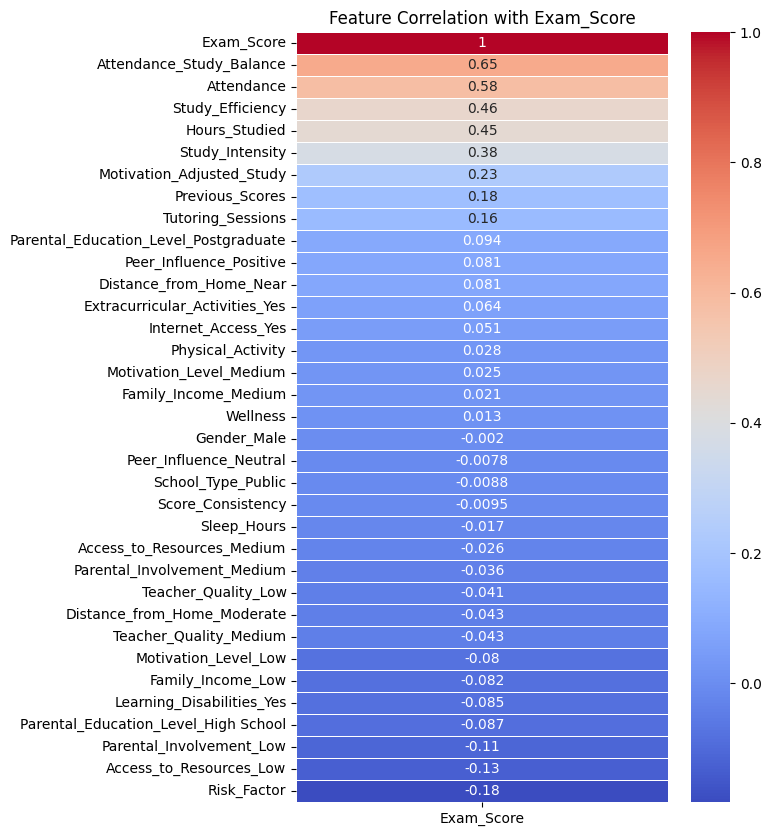

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# combine X and target
df_corr = X.copy()
df_corr["Exam_Score"] = y

# compute correlation matrix
corr_matrix = df_corr.corr()

# extract correlations with target only
target_corr = corr_matrix[["Exam_Score"]].sort_values(by="Exam_Score", ascending=False)

# plot heatmap
plt.figure(figsize=(6, 10))
sns.heatmap(target_corr, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation with Exam_Score")
plt.show()

EDA

In [ ]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nSummary :")
print(df.describe())

Shape: (6607, 20)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence         

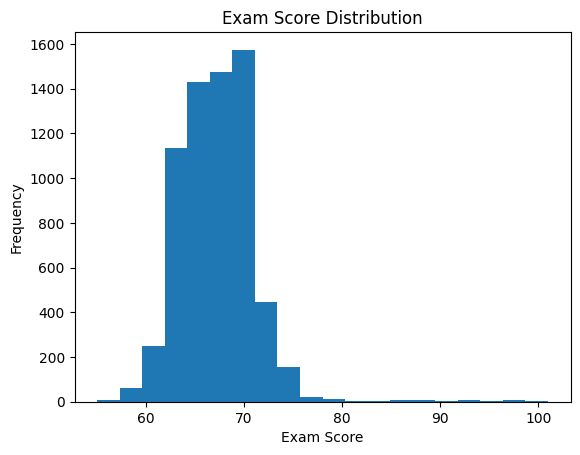

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(y, bins=20)
plt.title("Exam Score distribution")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

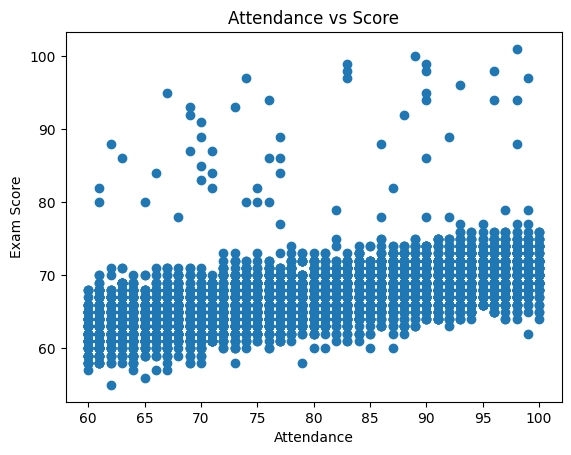

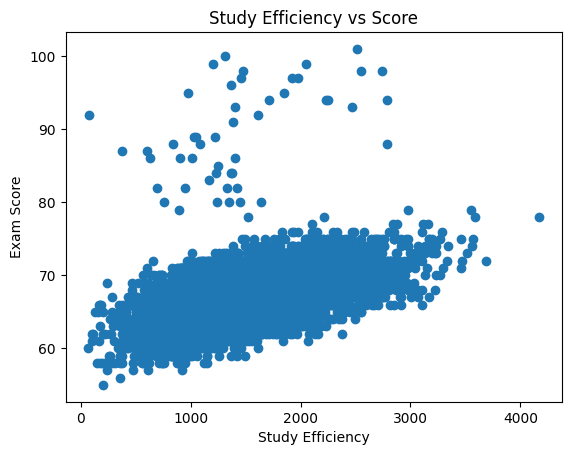

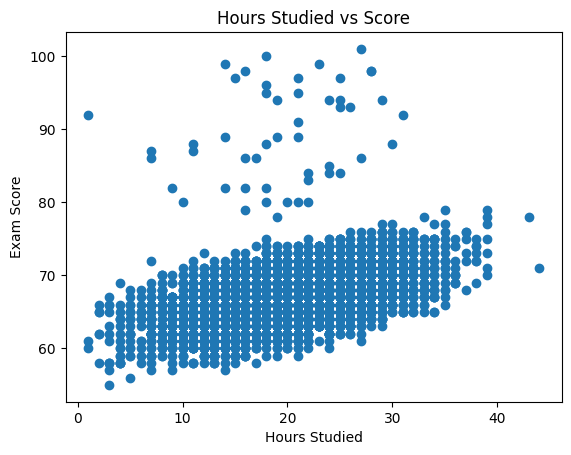

In [ ]:
# Attendance
plt.figure()
plt.scatter(X["Attendance"], y)
plt.title("Attendance vs Score")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.show()

# Study Efficiency
plt.figure()
plt.scatter(X["Study_Efficiency"], y)
plt.title("Study Efficiency vs Score")
plt.xlabel("Study Efficiency")
plt.ylabel("Exam Score")
plt.show()

# Hours Studied
plt.figure()
plt.scatter(X["Hours_Studied"], y)
plt.title("Hours Studied vs Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

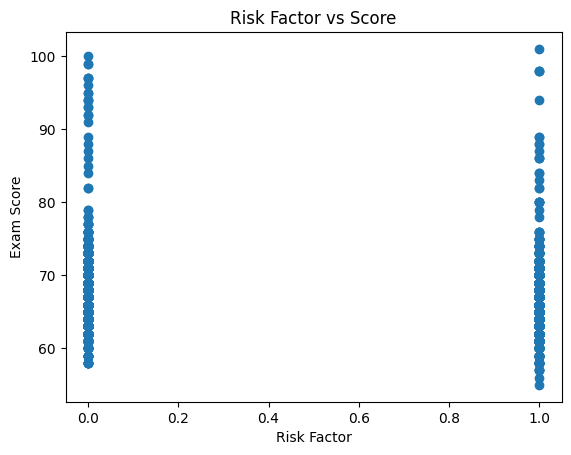

In [ ]:
plt.figure()
plt.scatter(X["Risk_Factor"], y)
plt.title("Risk Factor versus Score")
plt.xlabel("Risk Factor")
plt.ylabel("Exam Score")
plt.show()

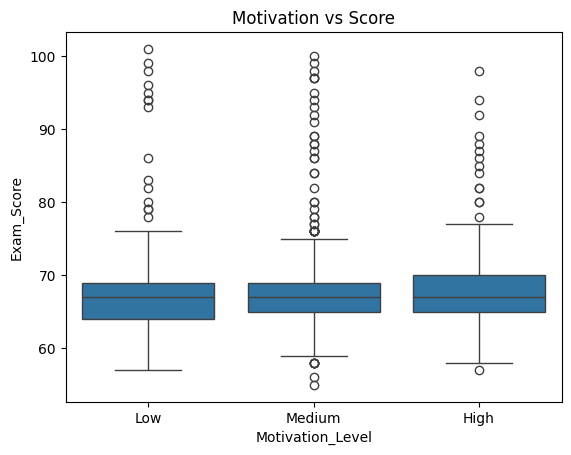

In [ ]:
import seaborn as sns

plt.figure()
sns.boxplot(x=df["Motivation_Level"], y=y)
plt.title("Motivation level vs Score")
plt.show()